In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier


# 1. Load the dataset
df = pd.read_csv('/content/hotel_bookings.csv')

In [ ]:
# Set aesthetic parameters for the plots
sns.set(style="whitegrid")

# 1. Missing Values Analysis
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])



Missing values per column:
children         4
country        488
agent        16340
company     112593
dtype: int64


/tmp/ipython-input-2709072151.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, palette='viridis')


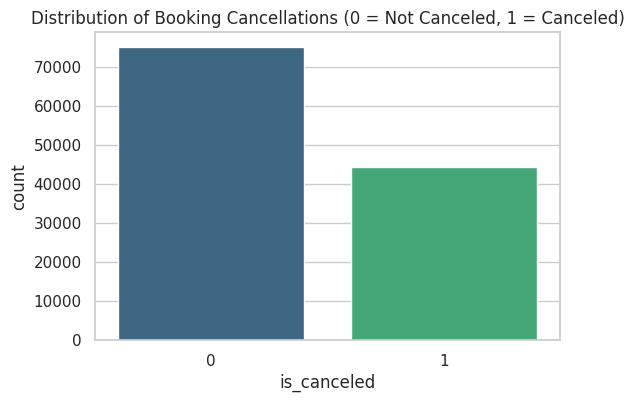

In [ ]:
# 2. Target Variable Distribution (is_canceled)
# Helps understand the balance between cancellations and successful stays
plt.figure(figsize=(6, 4))
sns.countplot(x='is_canceled', data=df, palette='viridis')
plt.title('Distribution of Booking Cancellations (0 = Not Canceled, 1 = Canceled)')
plt.show()


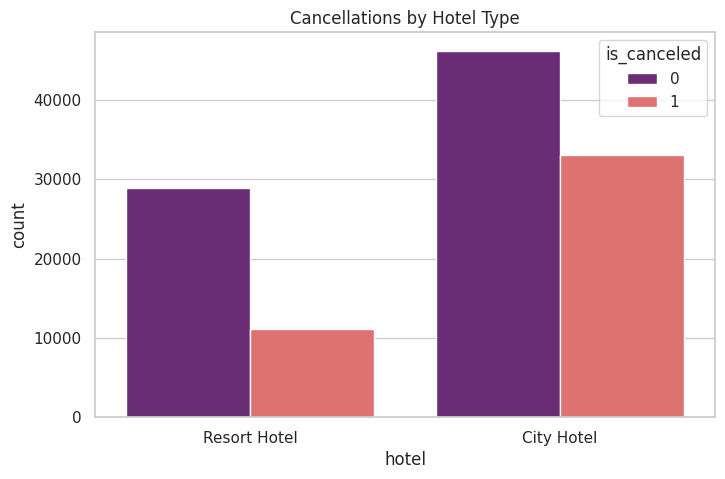

In [ ]:

# 3. Cancellations by Hotel Type
# Comparing Resort vs City Hotel cancellation behavior
plt.figure(figsize=(8, 5))
sns.countplot(x='hotel', hue='is_canceled', data=df, palette='magma')
plt.title('Cancellations by Hotel Type')
plt.show()


/tmp/ipython-input-2008011724.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='arrival_date_month', data=df, order=month_order, palette='Set3')


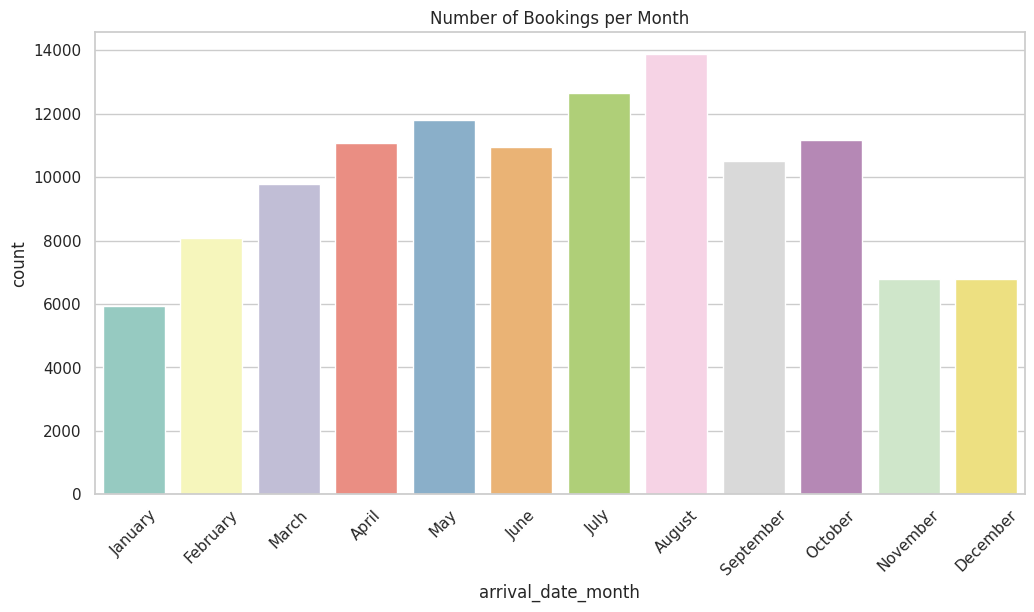

In [ ]:

# 4. Monthly Arrival Trends
# Visualizing seasonal demand
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
plt.figure(figsize=(12, 6))
sns.countplot(x='arrival_date_month', data=df, order=month_order, palette='Set3')
plt.title('Number of Bookings per Month')
plt.xticks(rotation=45)
plt.show()


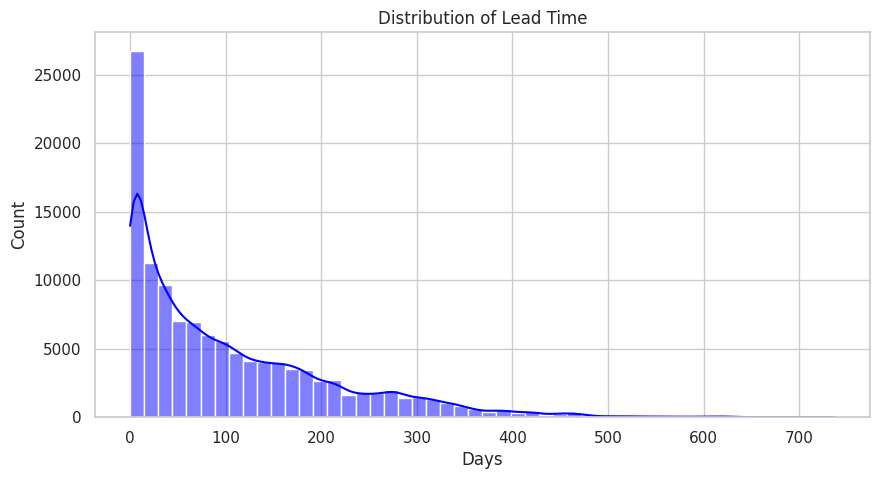

In [ ]:

# 5. Lead Time Distribution
# Seeing how far in advance guests book their rooms
plt.figure(figsize=(10, 5))
sns.histplot(df['lead_time'], bins=50, kde=True, color='blue')
plt.title('Distribution of Lead Time')
plt.xlabel('Days')
plt.show()


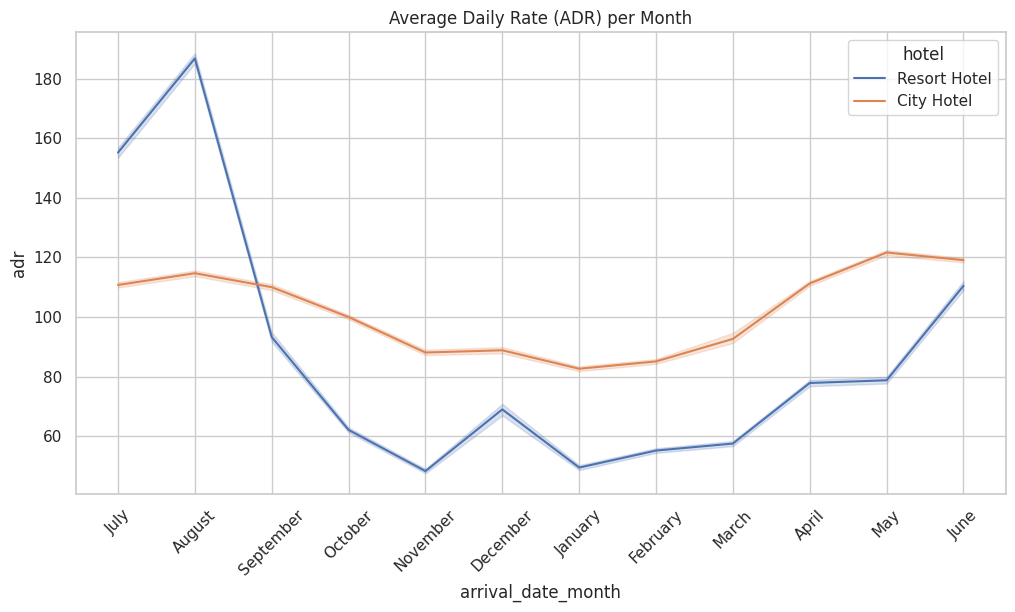

In [ ]:

# 6. Average Daily Rate (ADR) across Months
# Analyzing pricing seasonality for both hotels
plt.figure(figsize=(12, 6))
sns.lineplot(x='arrival_date_month', y='adr', hue='hotel', data=df, sort=False)
plt.title('Average Daily Rate (ADR) per Month')
plt.xticks(rotation=45)
plt.show()


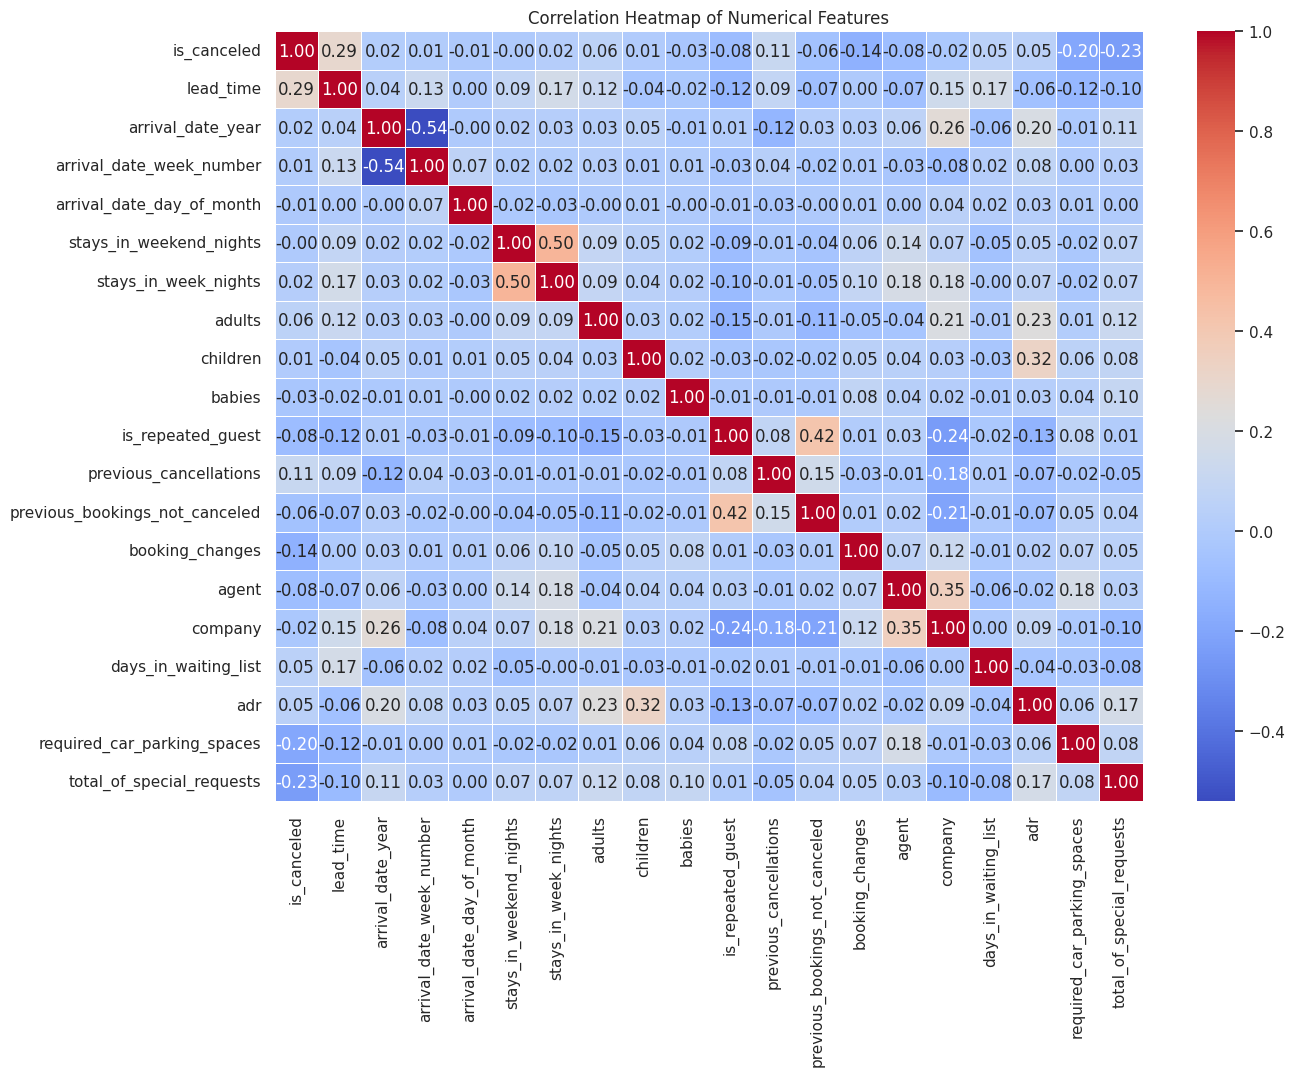

In [ ]:

# 7. Correlation Heatmap
# Identifying relationships between numerical features
plt.figure(figsize=(14, 10))
correlation = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

/tmp/ipython-input-2768663221.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='market_segment', data=df,


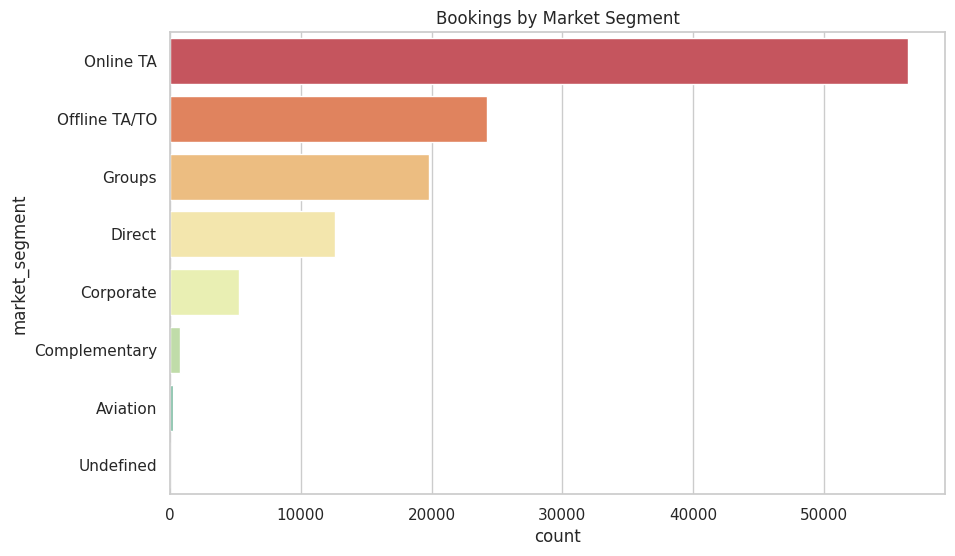

In [ ]:


# 8. Market Segment Analysis
# Identifying where the bookings are coming from
plt.figure(figsize=(10, 6))
sns.countplot(y='market_segment', data=df,
              order=df['market_segment'].value_counts().index, palette='Spectral')
plt.title('Bookings by Market Segment')
plt.show()


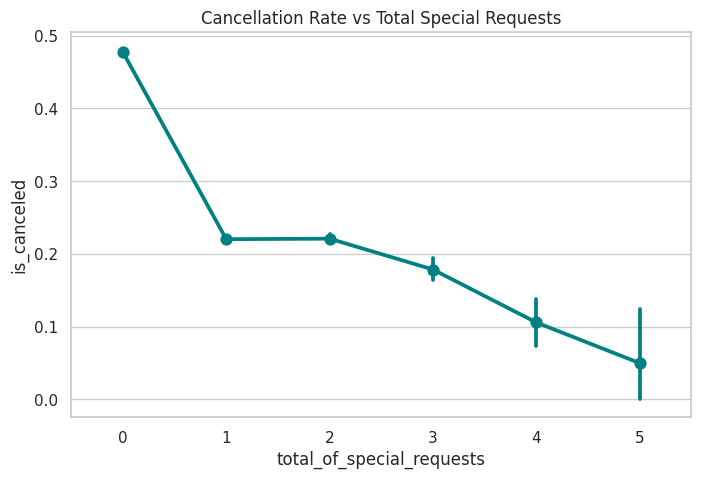

In [ ]:

# 9. Special Requests vs Cancellation
# Checking if guests with special requests are less likely to cancel
plt.figure(figsize=(8, 5))
sns.pointplot(x='total_of_special_requests', y='is_canceled', data=df, color='teal')
plt.title('Cancellation Rate vs Total Special Requests')
plt.show()

In [ ]:
# 2. Data Preparation & Cleaning
# Fill missing values: median for numerical, mode for categorical
df['children'] = df['children'].fillna(df['children'].median())
df['country'] = df['country'].fillna(df['country'].mode()[0])
# Fill ID-based missing values with 0 (representing 'None')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)
# Drop 'Data Leakage' columns
# 'reservation_status' tells you if it was canceled in advance;
# including it would make the model "cheat."
df_model = df.drop(['reservation_status', 'reservation_status_date', 'arrival_date_year'], axis=1)

In [ ]:
# 3. Categorical Encoding
# Convert text columns into numbers using One-Hot Encoding
categorical_cols = df_model.select_dtypes(include=['object']).columns
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

In [ ]:
# 4. Split Data into Features (X) and Target (y)
X = df_model.drop('is_canceled', axis=1)
y = df_model['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 5. Feature Scaling
# Logistic Regression performs significantly better when features are on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Classification work (Predicting canceled room)**

Logistic Regression

In [ ]:
# 6. Basic Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# 7. Evaluation
y_pred = model.predict(X_test_scaled)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 82.15%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86     14907
           1       0.82      0.67      0.74      8971

    accuracy                           0.82     23878
   macro avg       0.82      0.79      0.80     23878
weighted avg       0.82      0.82      0.82     23878



Random Forest

In [ ]:

# Drop data leakage and less relevant columns
df_model = df.drop(['reservation_status', 'reservation_status_date', 'arrival_date_year'], axis=1)

# 3. Categorical Encoding (One-Hot Encoding)
categorical_cols = df_model.select_dtypes(include=['object']).columns
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# 4. Split Data
X = df_model.drop('is_canceled', axis=1)
y = df_model['is_canceled']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Random Forest Model
# n_estimators=100 uses 100 decision trees; n_jobs=-1 uses all CPU cores for faster training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 6. Evaluation
y_pred_rf = rf_model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# 7. Extracting Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Most Influential Features for Prediction:")
print(feature_importance_df.head(5))

Random Forest Accuracy: 89.47%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92     14907
           1       0.90      0.81      0.85      8971

    accuracy                           0.89     23878
   macro avg       0.90      0.88      0.89     23878
weighted avg       0.89      0.89      0.89     23878


Top 5 Most Influential Features for Prediction:
                       Feature  Importance
0                    lead_time    0.121492
168                country_PRT    0.074266
15                         adr    0.073701
241    deposit_type_Non Refund    0.073181
17   total_of_special_requests    0.057302


**Regression Work (Calculating Revenue)**

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load the dataset
df = pd.read_csv('hotel_bookings.csv')

# --- 2. Data Preparation for Regression ---

# Filter out cancellations: We only want to predict revenue for realized stays
df_model = df[df['is_canceled'] == 0].copy()

# Remove extreme outliers in ADR
# The dataset has a known erroneous entry of 5400 and some zero/negative rates
df_model = df_model[(df_model['adr'] > 0) & (df_model['adr'] < 5000)]

# Handle missing values
df_model['children'] = df_model['children'].fillna(df_model['children'].median())
df_model['country'] = df_model['country'].fillna(df_model['country'].mode()[0])
df_model['agent'] = df_model['agent'].fillna(0)
df_model['company'] = df_model['company'].fillna(0)

# Drop irrelevant columns and features that leak data
cols_to_drop = ['is_canceled', 'reservation_status', 'reservation_status_date', 'arrival_date_year']
df_model = df_model.drop(cols_to_drop, axis=1)

# Encode Categorical Variables (One-Hot Encoding)
categorical_cols = df_model.select_dtypes(include=['object']).columns
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Define Features (X) and Target (y)
X = df_model.drop('adr', axis=1)
y = df_model['adr']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Crucial for Linear Regression distance calculations)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Linear Regression

In [ ]:

# --- 3. Linear Regression Model ---
# Note: Using Ridge (Regularized Linear Regression) is highly recommended here
# because standard LinearRegression struggles with the massive number of columns
# created by One-Hot Encoding the 'country' variable.
lr_model = Ridge(alpha=1.0)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

print("--- Regularized Linear Regression (Ridge) Performance ---")
print(f"Mean Absolute Error (MAE): ${mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"Root Mean Squared Error (RMSE): ${np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"R-squared: {r2_score(y_test, y_pred_lr):.4f}\n")


--- Regularized Linear Regression (Ridge) Performance ---
Mean Absolute Error (MAE): $21.50
Root Mean Squared Error (RMSE): $29.87
R-squared: 0.6149



Gradient Boosting Regressor

In [ ]:
# --- 4. Gradient Boosting Regressor Model ---
gbr_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_gbr = gbr_model.predict(X_test_scaled)

print("--- Gradient Boosting Regressor Performance ---")
print(f"Mean Absolute Error (MAE): ${mean_absolute_error(y_test, y_pred_gbr):.2f}")
print(f"Root Mean Squared Error (RMSE): ${np.sqrt(mean_squared_error(y_test, y_pred_gbr)):.2f}")
print(f"R-squared: {r2_score(y_test, y_pred_gbr):.4f}")

# Optional: See which features dictate the price most heavily
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gbr_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Features driving ADR (Price):")
print(feature_importance.head(5))

--- Gradient Boosting Regressor Performance ---
Mean Absolute Error (MAE): $16.97
Root Mean Squared Error (RMSE): $24.01
R-squared: 0.7511

Top 5 Features driving ADR (Price):
                      Feature  Importance
1    arrival_date_week_number    0.189017
17         hotel_Resort Hotel    0.139093
18  arrival_date_month_August    0.093954
6                    children    0.091391
5                      adults    0.086069


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor

# 1. Load the dataset
df = pd.read_csv('/content/hotel_bookings.csv')

# --- DATA PREPARATION FUNCTION ---
# We write a quick function to avoid repeating the cleaning code
def prepare_data(df, task='classification'):
    # Basic cleaning
    df_clean = df.copy()
    df_clean['children'] = df_clean['children'].fillna(df_clean['children'].median())
    df_clean['country'] = df_clean['country'].fillna(df_clean['country'].mode()[0])
    df_clean['agent'] = df_clean['agent'].fillna(0)
    df_clean['company'] = df_clean['company'].fillna(0)

    # Task specific cleaning
    if task == 'classification':
        df_clean = df_clean.drop(['reservation_status', 'reservation_status_date', 'arrival_date_year'], axis=1)
        # One-Hot Encode
        cat_cols = df_clean.select_dtypes(include=['object']).columns
        df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
        X = df_clean.drop('is_canceled', axis=1)
        y = df_clean['is_canceled']

    elif task == 'regression':
        # Filter for actual arrivals and clean ADR outliers
        df_clean = df_clean[df_clean['is_canceled'] == 0]
        df_clean = df_clean[(df_clean['adr'] > 0) & (df_clean['adr'] < 5000)]
        df_clean = df_clean.drop(['is_canceled', 'reservation_status', 'reservation_status_date', 'arrival_date_year'], axis=1)
        # One-Hot Encode
        cat_cols = df_clean.select_dtypes(include=['object']).columns
        df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
        X = df_clean.drop('adr', axis=1)
        y = df_clean['adr']

    return train_test_split(X, y, test_size=0.2, random_state=42)

# Get Data
X_train_c, X_test_c, y_train_c, y_test_c = prepare_data(df, task='classification')
X_train_r, X_test_r, y_train_r, y_test_r = prepare_data(df, task='regression')

# Scaling (Required for Linear models)
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)


# ==========================================
# HYPERPARAMETER TUNING: CLASSIFICATION
# ==========================================
print("\n--- Tuning Classification Models ---")

# 1. Logistic Regression
# C is the inverse of regularization strength; smaller values specify stronger regularization.
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2']
}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=3, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_c_scaled, y_train_c)
print(f"Logistic Regression Best Params: {grid_lr.best_params_}")
print(f"Logistic Regression Best Accuracy: {grid_lr.best_score_:.4f}")

# 2. Random Forest Classifier
# n_estimators: Number of trees, max_depth: How deep trees go, min_samples_split: limits overfitting
param_grid_rf = {
    'n_estimators': [100,200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
# Note: RF doesn't require standard scaling
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_c, y_train_c)
print(f"Random Forest Best Params: {grid_rf.best_params_}")
print(f"Random Forest Best Accuracy: {grid_rf.best_score_:.4f}")


# ==========================================
# HYPERPARAMETER TUNING: REGRESSION
# ==========================================
print("\n--- Tuning Regression Models ---")

# 3. Ridge Regression (Linear Regression with L2 Regularization)
# Alpha is the regularization strength. Higher alpha = simpler model (less overfitting).
param_grid_ridge = {
    'alpha': [0.1, 1.0, 10.0, 100.0, 500.0]
}
grid_ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_ridge.fit(X_train_r_scaled, y_train_r)
print(f"Ridge Regression Best Params: {grid_ridge.best_params_}")
# Note: GridSearchCV returns negative MAE so that higher is better during the search.
# We multiply by -1 to get the actual dollar amount error.
print(f"Ridge Regression Best CV MAE: ${-grid_ridge.best_score_:.2f}")

# 4. Gradient Boosting Regressor
# learning_rate: step size, max_depth: complexity of individual trees
param_grid_gbr = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
grid_gbr = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gbr, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_gbr.fit(X_train_r_scaled, y_train_r)
print(f"Gradient Boosting Regressor Best Params: {grid_gbr.best_params_}")
print(f"Gradient Boosting Best CV MAE: ${-grid_gbr.best_score_:.2f}")


--- Tuning Classification Models ---
Logistic Regression Best Params: {'C': 0.1, 'penalty': 'l2'}
Logistic Regression Best Accuracy: 0.8172


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Best Accuracy: 0.8849

--- Tuning Regression Models ---
Ridge Regression Best Params: {'alpha': 1.0}
Ridge Regression Best CV MAE: $21.41
Gradient Boosting Regressor Best Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Gradient Boosting Best CV MAE: $10.79


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# 0. Load and Prepare Data
# ==========================================
df = pd.read_csv('/content/hotel_bookings.csv')

def prepare_data(df, task='classification'):
    df_clean = df.copy()
    # Basic Imputation
    df_clean['children'] = df_clean['children'].fillna(df_clean['children'].median())
    df_clean['country'] = df_clean['country'].fillna(df_clean['country'].mode()[0])
    df_clean['agent'] = df_clean['agent'].fillna(0)
    df_clean['company'] = df_clean['company'].fillna(0)

    if task == 'classification':
        df_clean = df_clean.drop(['reservation_status', 'reservation_status_date', 'arrival_date_year'], axis=1)
        cat_cols = df_clean.select_dtypes(include=['object']).columns
        df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
        X = df_clean.drop('is_canceled', axis=1)
        y = df_clean['is_canceled']

    elif task == 'regression':
        df_clean = df_clean[df_clean['is_canceled'] == 0]
        df_clean = df_clean[(df_clean['adr'] > 0) & (df_clean['adr'] < 5000)]
        df_clean = df_clean.drop(['is_canceled', 'reservation_status', 'reservation_status_date', 'arrival_date_year'], axis=1)
        cat_cols = df_clean.select_dtypes(include=['object']).columns
        df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
        X = df_clean.drop('adr', axis=1)
        y = df_clean['adr']

    # Deep Learning REQUIRES features to be heavily standardized
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, X.shape[1]

# Set up an Early Stopping callback to prevent overfitting
# This stops training if the validation loss doesn't improve for 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ==========================================
# 1. Deep Learning for Classification (is_canceled)
# ==========================================
print("\n--- Training Classification DNN ---")
X_train_c, X_test_c, y_train_c, y_test_c, input_dim_c = prepare_data(df, task='classification')

# Build the Neural Network Architecture
model_classifier = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim_c,)),
    BatchNormalization(),         # Normalizes outputs of the previous layer to stabilize training
    Dropout(0.3),                 # Randomly turns off 30% of neurons to prevent overfitting

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid') # Sigmoid compresses output between 0 and 1 (Probability)
])

# Compile the model
model_classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history_c = model_classifier.fit(
    X_train_c, y_train_c,
    epochs=50,
    batch_size=128,
    validation_split=0.2, # Uses 20% of training data to check for overfitting every epoch
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
loss_c, acc_c = model_classifier.evaluate(X_test_c, y_test_c, verbose=0)
print(f"Classification Model Test Accuracy: {acc_c:.4f}")


# ==========================================
# 2. Deep Learning for Regression (adr / Revenue)
# ==========================================
print("\n--- Training Regression DNN ---")
X_train_r, X_test_r, y_train_r, y_test_r, input_dim_r = prepare_data(df, task='regression')

# Build the Neural Network Architecture
model_regressor = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim_r,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear') # Linear activation for continuous numerical output
])

# Compile the model
# Using Mean Absolute Error (MAE) as the loss function to minimize dollar difference
model_regressor.compile(optimizer='adam', loss='mean_absolute_error', metrics=['mae'])

# Train the model
history_r = model_regressor.fit(
    X_train_r, y_train_r,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
loss_r, mae_r = model_regressor.evaluate(X_test_r, y_test_r, verbose=0)
print(f"Regression Model Test Mean Absolute Error (MAE): ${mae_r:.2f}")


--- Training Classification DNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
597/597 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7895 - loss: 0.4294 - val_accuracy: 0.8292 - val_loss: 0.3611
Epoch 2/50
597/597 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8242 - loss: 0.3643 - val_accuracy: 0.8371 - val_loss: 0.3450
Epoch 3/50
597/597 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8318 - loss: 0.3497 - val_accuracy: 0.8382 - val_loss: 0.3395
Epoch 4/50
597/597 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8377 - loss: 0.3398 - val_accuracy: 0.8424 - val_loss: 0.3317
Epoch 5/50
597/597 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8423 - loss: 0.3336 - val_accuracy: 0.8440 - val_loss: 0.3288
Epoch 6/50
597/597 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8426 - loss: 0.3292 - val_accuracy: 0.8456 - val_loss: 0.3251
Epoch 7/50
597/597 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8447 - loss: 0.3265 - val_accuracy: 0.8498 - val_loss: 0.3202
Epoch 8/50
597/597 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8479 - loss: 0.3210 - val_accuracy: 0.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


735/735 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 22.9020 - mae: 22.9020 - val_loss: 16.9500 - val_mae: 16.9500
Epoch 2/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 16.0505 - mae: 16.0505 - val_loss: 15.9490 - val_mae: 15.9490
Epoch 3/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 15.1413 - mae: 15.1413 - val_loss: 15.4914 - val_mae: 15.4914
Epoch 4/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 14.6325 - mae: 14.6325 - val_loss: 15.7719 - val_mae: 15.7719
Epoch 5/100
735/735 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 14.2349 - mae: 14.2349 - val_loss: 15.1276 - val_mae: 15.1276
Regression Model Test Mean Absolute Error (MAE): $16.85


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('hotel_bookings.csv')

# Convert month name to number
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
             'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12}
df['arrival_date_month'] = df['arrival_date_month'].map(month_map)

# Create a 'arrival_date' column
df['arrival_date'] = pd.to_datetime(df[['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month']]
                                   .astype(str).agg('-'.join, axis=1))

# Set arrival_date as the index
df.set_index('arrival_date', inplace=True)

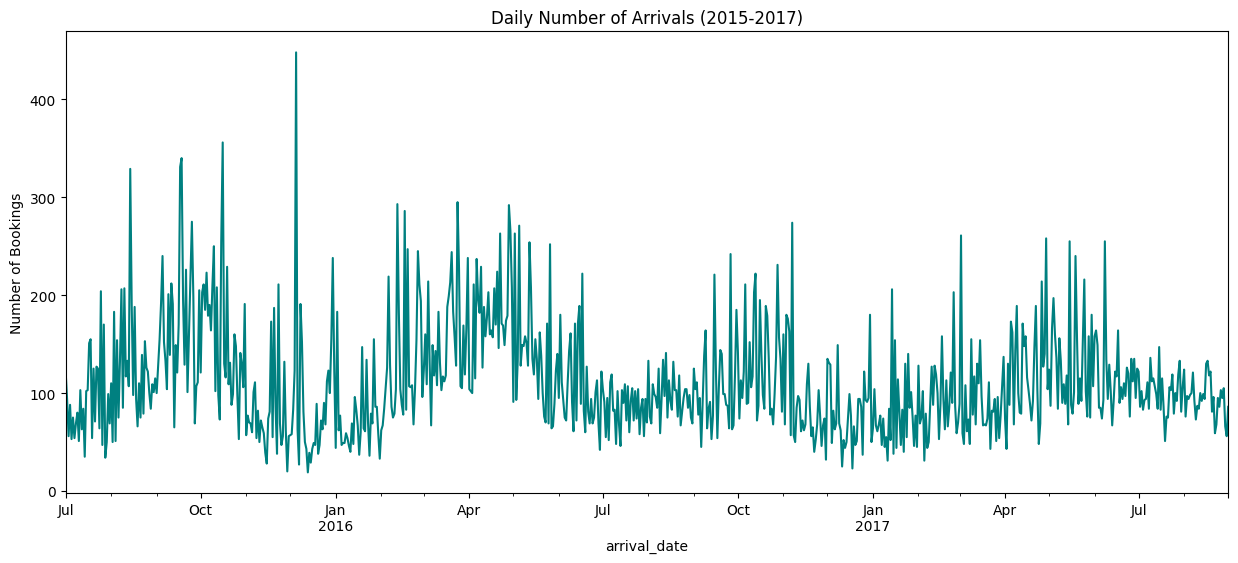

In [2]:
# Count bookings per day
daily_bookings = df.resample('D').size()

plt.figure(figsize=(15, 6))
daily_bookings.plot(title='Daily Number of Arrivals (2015-2017)', color='teal')
plt.ylabel('Number of Bookings')
plt.show()